In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import LabelEncoder
from sklearn.discriminant_analysis import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve

In [16]:
df = pd.read_csv('../data/Churn_Modelling.csv')
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [17]:
# Geography와 Gender 열 변환
le_geo = LabelEncoder()
le_gender = LabelEncoder()

df['Geography'] = le_geo.fit_transform(df['Geography'])
df['Gender'] = le_gender.fit_transform(df['Gender'])

X = df.drop(columns=['Exited'])

scaler = StandardScaler()
X = scaler.fit_transform(X)

y = df['Exited'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [18]:
# SVC 모델 정의
svc = SVC()

# 탐색할 하이퍼파라미터 정의
params = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001]
}

# GridSearchCV 객체 생성
grid_search = GridSearchCV(svc, param_grid=params, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# 학습
grid_search.fit(X_train, y_train)

# 최적 하이퍼파라미터 출력
print("Best parameters found: ", grid_search.best_params_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters found:  {'C': 1000, 'gamma': 0.01}


In [19]:
# 검증 데이터로 예측
y_pred = grid_search.best_estimator_.predict(X_test)

# 정확도
acc = accuracy_score(y_test, y_pred)
print("✅ Accuracy:", acc)

# 정밀도, 재현율, F1 등 전체 리포트
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

✅ Accuracy: 0.861

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.43      0.56       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



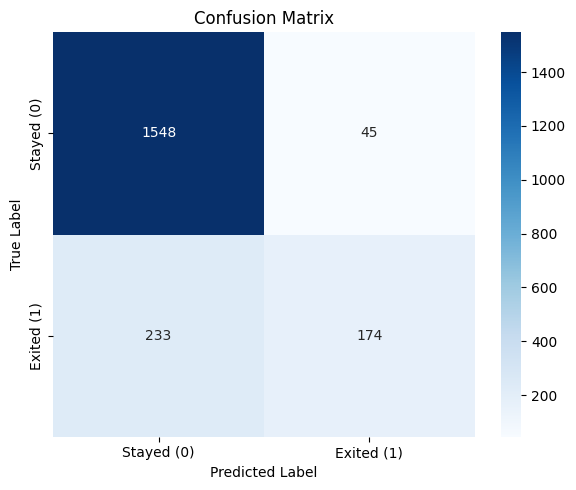

In [20]:
# 혼동 행렬 계산
cm = confusion_matrix(y_test, y_pred)

# 라벨 지정 (0: 잔류, 1: 이탈)
labels = ['Stayed (0)', 'Exited (1)']

# 시각화
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()



🔥 AUC Score: 0.6996


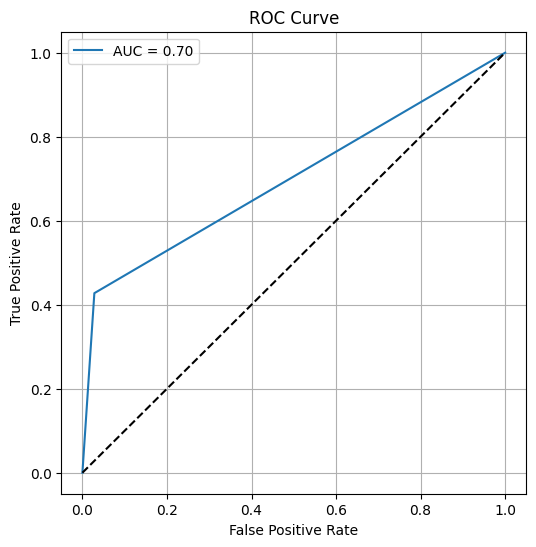

In [ ]:
# AUC 계산
auc = roc_auc_score(y_test, y_pred)
print(f"\n🔥 AUC Score: {auc:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # 대각선
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()